In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv
/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat
/kaggle/input/datasets/zerotrace11/tech-company-dataset/tech_company_employee_data_1000.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
uci = pd.read_csv('/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv')
diabetes = pd.read_csv('/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
titanic = pd.read_csv('/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv')
house = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')

# impute missing values of occupation column of uci dataset

In [4]:
uci.head

<bound method NDFrame.head of        Age          Workclass  fnlwgt    Education  Education_Num  \
0       39          State-gov   77516    Bachelors             13   
1       50   Self-emp-not-inc   83311    Bachelors             13   
2       38            Private  215646      HS-grad              9   
3       53            Private  234721         11th              7   
4       28            Private  338409    Bachelors             13   
...    ...                ...     ...          ...            ...   
32556   27            Private  257302   Assoc-acdm             12   
32557   40            Private  154374      HS-grad              9   
32558   58            Private  151910      HS-grad              9   
32559   22            Private  201490      HS-grad              9   
32560   52       Self-emp-inc  287927      HS-grad              9   

            Martial_Status          Occupation    Relationship    Race  \
0            Never-married        Adm-clerical   Not-in-family   Wh

In [5]:
print(uci['Occupation'].isnull().sum())
print(uci['Occupation'].value_counts())

1843
Occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64


In [6]:
uci['Occupation'] = uci['Occupation'].fillna(uci['Occupation'].mode()[0])

print("Missing values after imputation:")
print(uci['Occupation'].isnull().sum())

Missing values after imputation:
0


In [7]:
print(uci['Occupation'].isnull().sum())
print(uci['Occupation'].value_counts())

0
Occupation
Prof-specialty       5983
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64


# Outliers

# 1. find and mitigate(trimming and capping both) outliers on age column of diabetes dataset

In [8]:
diabetes.head

<bound method NDFrame.head of        gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0              6.

In [9]:
Q1 = diabetes['age'].quantile(0.25)
Q3 = diabetes['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

outliers = diabetes[(diabetes['age'] < lower) | (diabetes['age'] > upper)]

print("Number of outliers:", len(outliers))
print(outliers['age'])

Q1: 24.0
Q3: 60.0
IQR: 36.0
Lower Bound: -30.0
Upper Bound: 114.0
Number of outliers: 0
Series([], Name: age, dtype: float64)


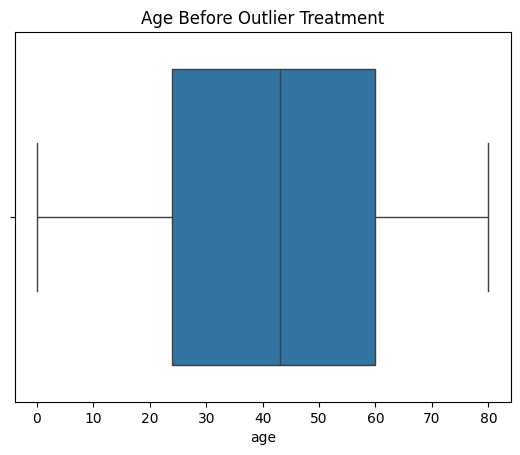

In [10]:
sns.boxplot(x=diabetes['age'])
plt.title("Age Before Outlier Treatment")
plt.show()

In [11]:
diabetes_trimmed = diabetes[
    (diabetes['age'] >= lower) &
    (diabetes['age'] <= upper)
]

print("Original rows:", len(diabetes))
print("Rows after trimming:", len(diabetes_trimmed))
print("Removed rows:", len(diabetes) - len(diabetes_trimmed))

Original rows: 100000
Rows after trimming: 100000
Removed rows: 0


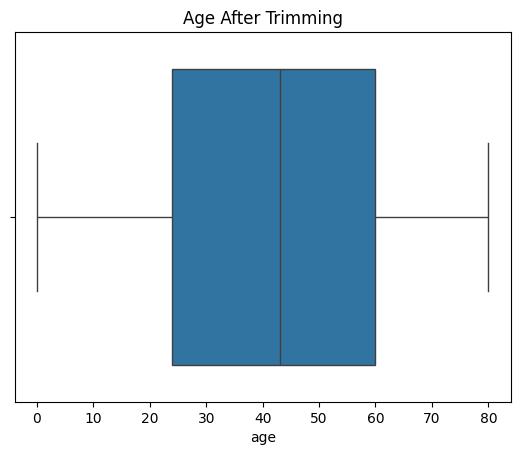

In [12]:
sns.boxplot(x=diabetes_trimmed['age'])
plt.title("Age After Trimming")
plt.show()

In [13]:
diabetes_capped = diabetes.copy()

diabetes_capped['age'] = diabetes_capped['age'].clip(
    lower=lower,
    upper=upper
)

print("Minimum age after capping:", diabetes_capped['age'].min())
print("Maximum age after capping:", diabetes_capped['age'].max())

Minimum age after capping: 0.08
Maximum age after capping: 80.0


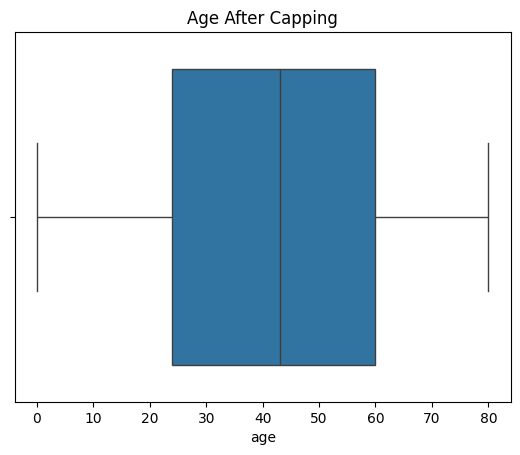

In [14]:
sns.boxplot(x=diabetes_capped['age'])
plt.title("Age After Capping")
plt.show()

# 2. find and mitigate(trimming and capping both) outliers on price column of house dataset

In [15]:
house.head

<bound method NDFrame.head of                      date         price  bedrooms  bathrooms  sqft_living  \
0     2014-05-02 00:00:00  3.130000e+05       3.0       1.50         1340   
1     2014-05-02 00:00:00  2.384000e+06       5.0       2.50         3650   
2     2014-05-02 00:00:00  3.420000e+05       3.0       2.00         1930   
3     2014-05-02 00:00:00  4.200000e+05       3.0       2.25         2000   
4     2014-05-02 00:00:00  5.500000e+05       4.0       2.50         1940   
...                   ...           ...       ...        ...          ...   
4595  2014-07-09 00:00:00  3.081667e+05       3.0       1.75         1510   
4596  2014-07-09 00:00:00  5.343333e+05       3.0       2.50         1460   
4597  2014-07-09 00:00:00  4.169042e+05       3.0       2.50         3010   
4598  2014-07-10 00:00:00  2.034000e+05       4.0       2.00         2090   
4599  2014-07-10 00:00:00  2.206000e+05       3.0       2.50         1490   

      sqft_lot  floors  waterfront  view  con

In [16]:
print(house['price'].describe())
print(house['price'].isnull().sum())

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64
0


In [17]:
Q1 = house['price'].quantile(0.25)
Q3 = house['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

outliers = house[
    (house['price'] < lower) |
    (house['price'] > upper)
]

print("Number of outliers:", len(outliers))
print(outliers['price'])

Q1: 322875.0
Q3: 654962.5
IQR: 332087.5
Lower Bound: -175256.25
Upper Bound: 1153093.75
Number of outliers: 240
1       2.384000e+06
11      1.400000e+06
14      1.200000e+06
99      1.395000e+06
122     2.280000e+06
            ...     
4348    2.199900e+06
4350    2.659000e+07
4465    2.560498e+06
4467    1.337044e+06
4572    1.288333e+06
Name: price, Length: 240, dtype: float64


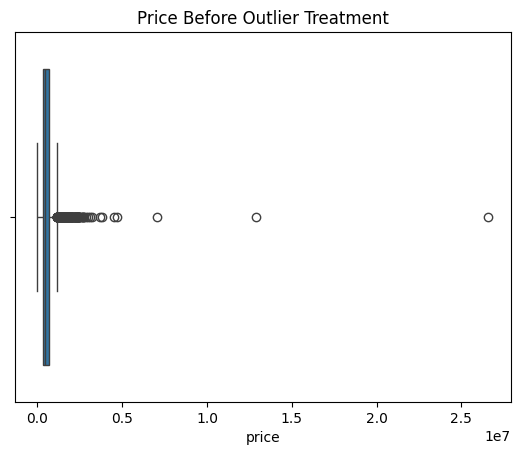

In [18]:
sns.boxplot(x=house['price'])
plt.title("Price Before Outlier Treatment")
plt.show()

In [19]:
house_trimmed = house[
    (house['price'] >= lower) &
    (house['price'] <= upper)
]

print("Original rows:", len(house))
print("Rows after trimming:", len(house_trimmed))
print("Removed rows:", len(house) - len(house_trimmed))

Original rows: 4600
Rows after trimming: 4360
Removed rows: 240


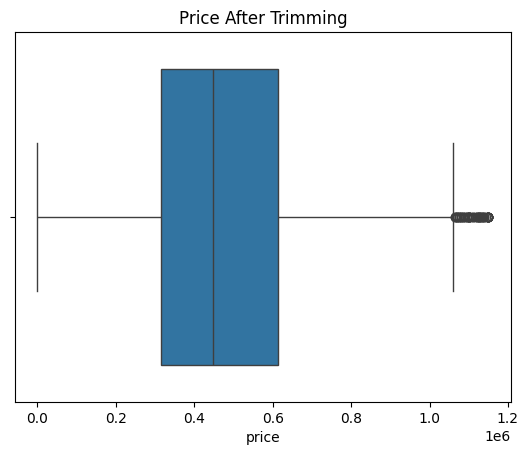

In [20]:
sns.boxplot(x=house_trimmed['price'])
plt.title("Price After Trimming")
plt.show()

In [21]:
house_capped = house.copy()

house_capped['price'] = house_capped['price'].clip(
    lower=lower,
    upper=upper
)

print("Minimum price after capping:", house_capped['price'].min())
print("Maximum price after capping:", house_capped['price'].max())

Minimum price after capping: 0.0
Maximum price after capping: 1153093.75


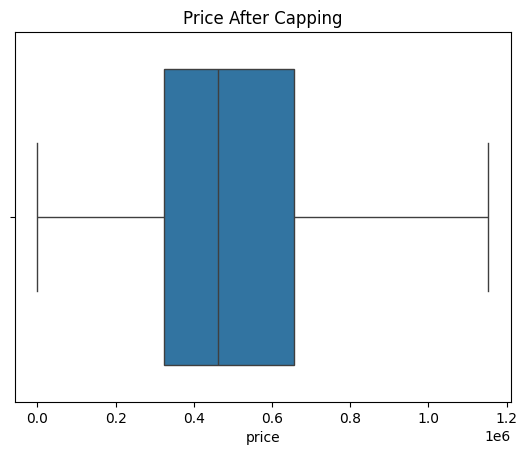

In [22]:
sns.boxplot(x=house_capped['price'])
plt.title("Price After Capping")
plt.show()